# 1. Introduction & Dataset Overview

- Dataset Name: iris
- Source URL: https://www.kaggle.com/datasets/uciml/iris


Description:

The Iris dataset was used in R.A. Fisher's classic 1936 paper, The Use of Multiple Measurements in Taxonomic Problems, and can also be found on the UCI Machine Learning Repository.

It includes three iris species with 50 samples each as well as some properties about each flower. One flower species is linearly separable from the other two, but the other two are not linearly separable from each other

Objectives:

To perform data analysis and visualization using Matplotlib, Seaborn, and Plotly, including data exploration, creating various chart types (line, bar, histogram, scatter, subplot grid, box plot, pair plot, correlation heatmap, interactive Plotly chart), generating insights for each visualization, summarizing key insights, and writing a conclusion.



# 2. Data Loading & Cleaning

In [5]:
import kagglehub
path = kagglehub.dataset_download("uciml/iris")

Using Colab cache for faster access to the 'iris' dataset.


In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv(f'{path}/Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# 3. Matplotlib Visualizations

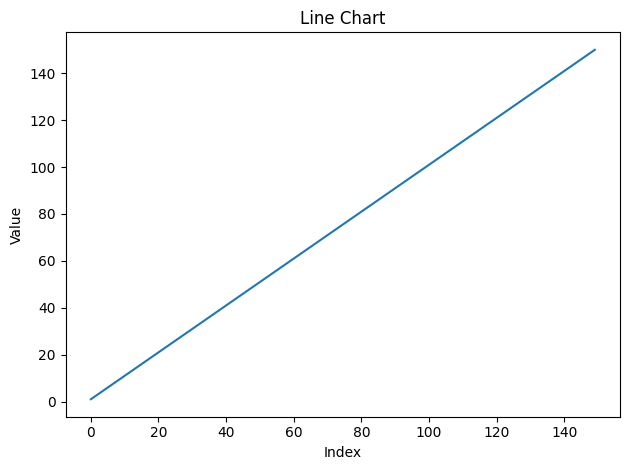

In [11]:
import matplotlib.pyplot as plt

# Line Chart
plt.plot(df.index, df.select_dtypes(include='number').iloc[:,0])
plt.title('Line Chart')
plt.xlabel('Index')
plt.ylabel('Value')
plt.tight_layout()
plt.savefig('line_chart.png', dpi=150)
plt.show()

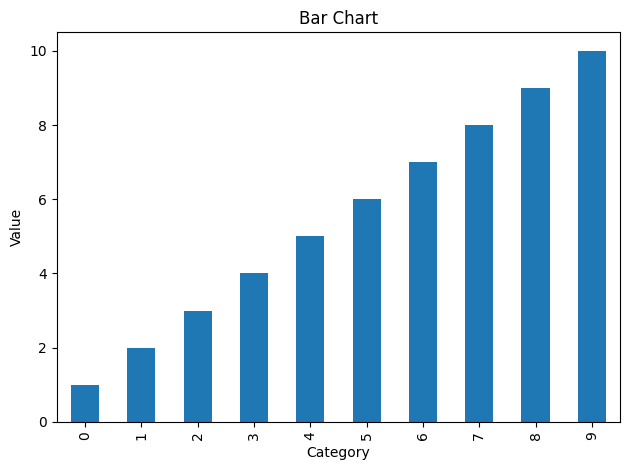

In [12]:
# Bar Chart
df.select_dtypes(include='number').iloc[:,0].head(10).plot(kind='bar')
plt.title('Bar Chart')
plt.xlabel('Category')
plt.ylabel('Value')
plt.tight_layout()
plt.savefig('bar_chart.png', dpi=150)
plt.show()

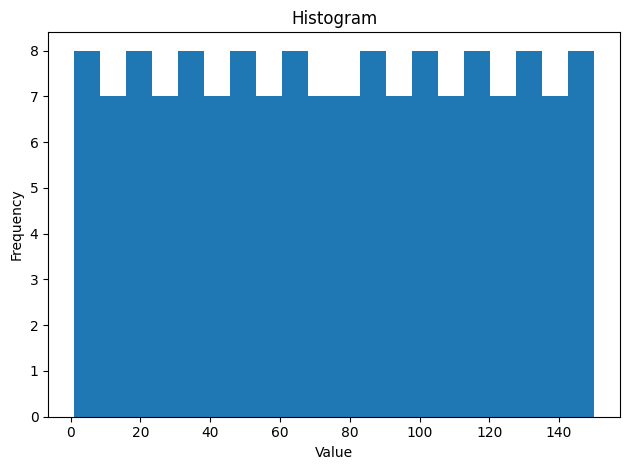

In [13]:
# Histogram
plt.hist(df.select_dtypes(include='number').iloc[:,0], bins=20)
plt.title('Histogram')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('histogram.png', dpi=150)
plt.show()

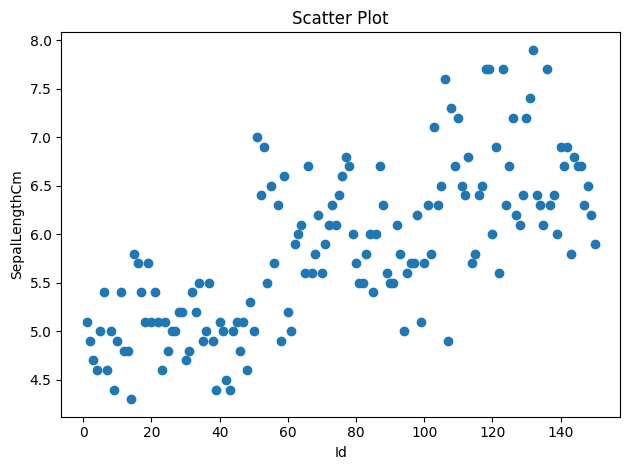

In [15]:
# Scatter Plot
num_cols = df.select_dtypes(include='number').columns
plt.scatter(df[num_cols[0]], df[num_cols[1]])
plt.title('Scatter Plot')
plt.xlabel(num_cols[0])
plt.ylabel(num_cols[1])
plt.tight_layout()
plt.savefig('scatter.png', dpi=150)
plt.show()

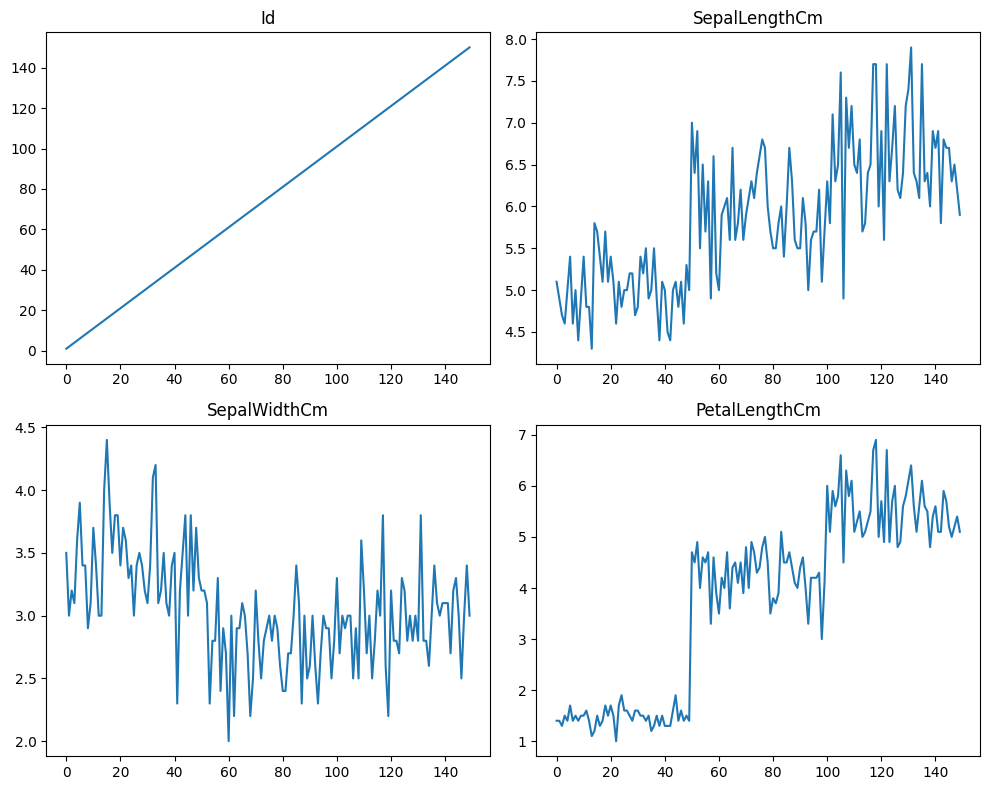

In [16]:
# Subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    if i < len(num_cols):
        ax.plot(df[num_cols[i]])
        ax.set_title(num_cols[i])
plt.tight_layout()
plt.savefig('subplots.png', dpi=150)
plt.show()

# 4. Seaborn Statistical Plots

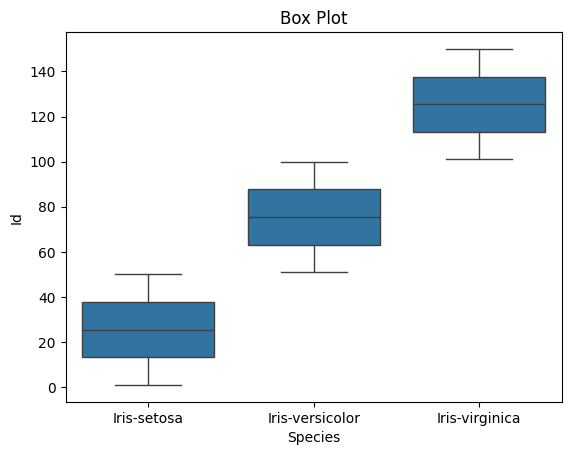

In [17]:
import seaborn as sns

# Box Plot
cat_col = df.select_dtypes(include='object').columns[0]
sns.boxplot(x=cat_col, y=num_cols[0], data=df)
plt.title('Box Plot')
plt.show()

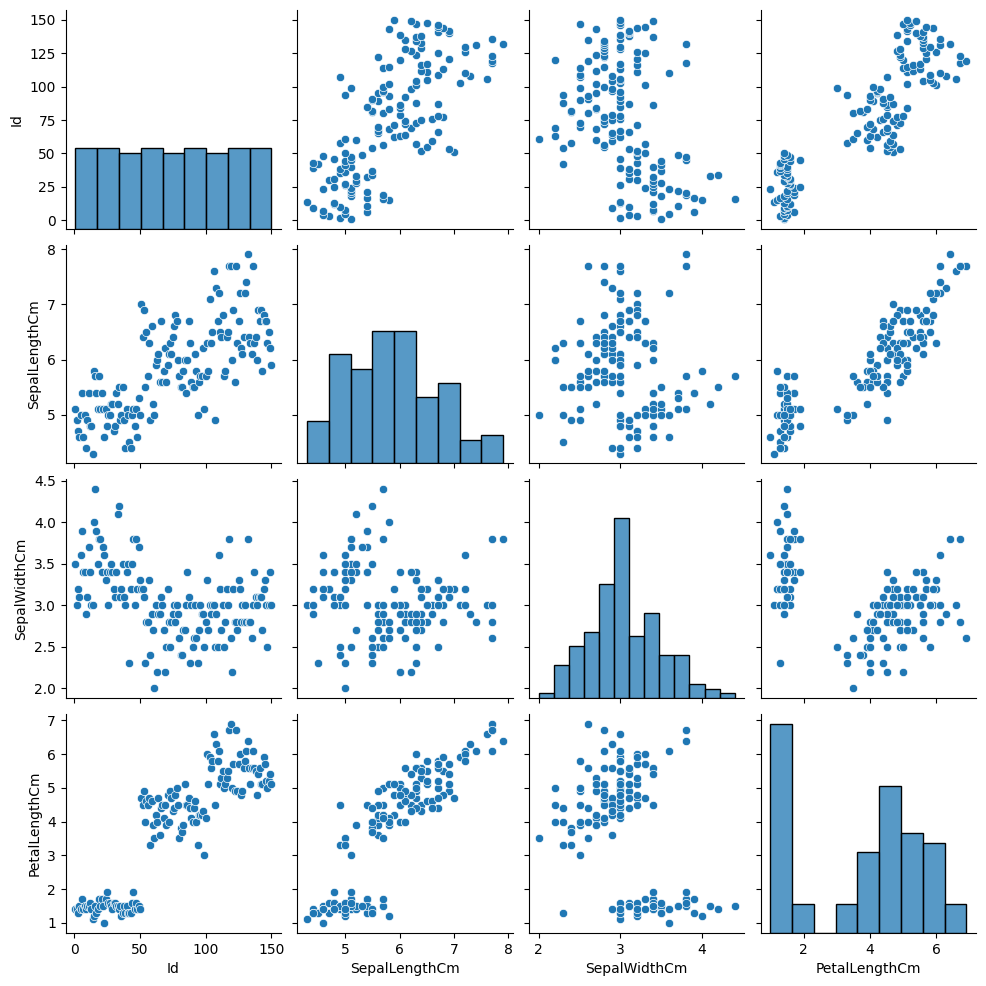

In [18]:
# Pair Plot
sns.pairplot(df[num_cols[:4]])
plt.show()

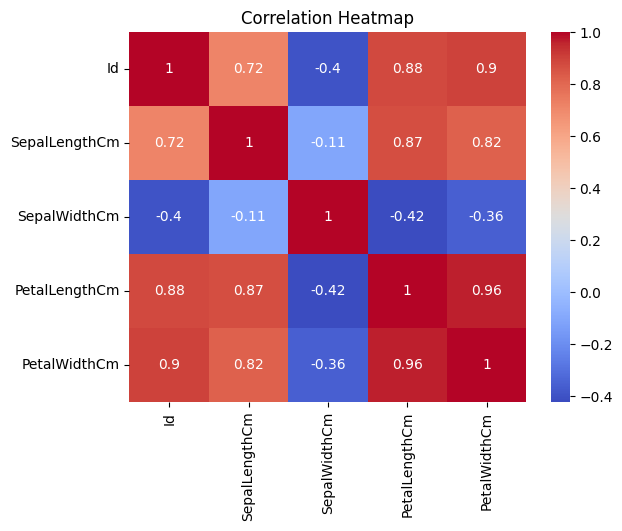

In [19]:
# Heatmap
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 5. Plotly Interactive Chart

In [20]:
import plotly.express as px

fig = px.scatter(df, x=num_cols[0], y=num_cols[1], color=cat_col if 'cat_col' in globals() else None)
fig.update_layout(title='Interactive Scatter Plot')
fig.show()

# Optional export
# fig.write_image('plotly_chart.png')

# 6. Insight Summary

Observation:

The interactive scatter plot shows a clear separation among the three Iris species based on petal length and petal width. Iris setosa forms a tightly grouped cluster with very small petal values, Iris versicolor occupies a moderate range, and Iris virginica exhibits the largest petal measurements.

Explanation:

This separation occurs because petal size varies significantly across species due to biological differences in flower structure. The minimal overlap between clusters indicates that petal dimensions are strong distinguishing features.

Implication:

Petal length and width can be effectively used for classification tasks, meaning even simple models or rules could accurately predict species. The Plotly interactivity further enhances analysis by allowing users to explore individual observations and examine additional attributes such as sepal measurements.


# 7. Conclusion

The analysis reveals that petal length and petal width are the most influential features for distinguishing between Iris species, as they provide clear and well-separated clusters. While sepal measurements add context, they are less decisive for classification. A limitation of this analysis is that it relies on a relatively small and well-structured dataset, which may not reflect real-world complexity. Future work could involve applying machine learning models to validate these findings or testing the approach on more complex biological datasets.